# EUROPEAN CALL OPTION WITH LOCAL VOLATILITY VIA BLACK SCHOLES

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import scipy

In [2]:
#risk free rate
r = 0.03

#dividends
q = 0.01

#strike price
K = 120.

#time to maturity
T = 1.

#width of transformed S coordinate
w = 1.5


In [3]:
#range of S's covered

K*np.exp(-w), K*np.exp(w)

(26.775619217811577, 537.8026884405677)

In [4]:
S0, sig0, beta, kappa, eta, lam = 100.0, 0.20, 0.45, 1.5, 0.35, 2.0


#beta, eta = 0., 0. #this gives sigma = sig0 fixed for all times and strikes

def sigma_lv(S, t):
    z = np.log(np.asarray(S, float)/S0)
    return sig0*(1.0 - beta*np.tanh(kappa*z))*(1.0 + eta*np.exp(-lam*t))

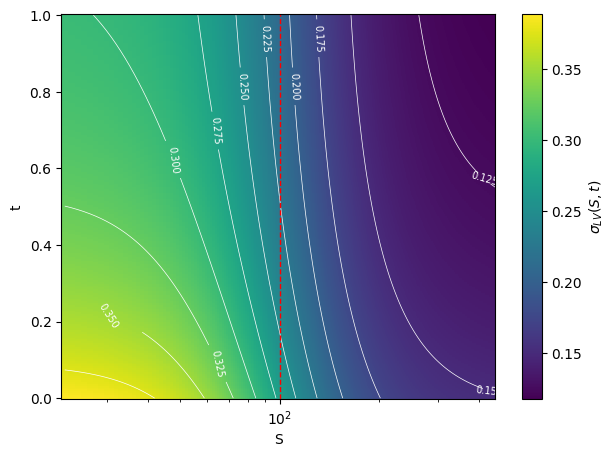

In [5]:
S = np.linspace(S0*np.exp(-w), S0*np.exp(w), 400)
t = np.linspace(0.0, T, 200)
SS, TT = np.meshgrid(S, t, indexing='ij')

plt.figure(figsize=(7,5))
pc = plt.pcolormesh(SS, TT, sigma_lv(SS, TT), shading='auto', cmap='viridis')
plt.colorbar(pc, label=r'$\sigma_{LV}(S,t)$')
cs = plt.contour(SS, TT, sigma_lv(SS, TT), levels=10, colors='w', linewidths=0.5)
plt.clabel(cs, fontsize=7)
plt.xscale('log')
plt.axvline(S0, color='r', ls='--', lw=1)
plt.xlabel('S'); plt.ylabel('t')
plt.show()

## Transformed Coordinate setup in $(\tau, x)$ and initial + boundary conditions

$$ \tau = T - t, \quad \tau (t=0) = T, \quad \tau (t=T) = 0 $$

$$ x = ln (\frac{S}{K}) , \quad x(S = K e^{-w}) = - w, \quad x(S = K e^{+w}) = w$$

$$ \partial_\tau f = \frac{1}{2} \sigma^2 \partial^2_x f + (r - q - \frac{1}{2}\sigma^2) \partial_x f - r f$$

$$ f(\tau =0, x) = max(K e^x - K, 0 )$$

$$ f(\tau, x = -w) = 0$$

$$ f(\tau, x = w) = K(e^w e^{-q \tau} - e^{-r \tau})$$



## Load in Chebyshev polynomials and match to initial data

In [6]:
n = 50

diff = np.loadtxt('../diffmatrix100.txt')[0:n,0:n]

chebyshevs = []
for i in range(0, n):
    chebyshevs.append(scipy.special.chebyt(i))

In [7]:
# tau array

tau = np.linspace(0, T, int(T/10**-3 + 1))
dtau = tau[1:] - tau[0:-1]

# solution array

c = np.zeros((len(tau), 2*n))


In [8]:
# transform to two numerical coordinates

def xnum_to_xleft(xnum):
    return (xnum - 1.)*(w/2) 

def xnum_to_xright(xnum):
    return (xnum + 1.)*(w/2)

In [9]:
def get_coeff(n, f, xnum_to_x):

    xcol = np.cos(np.pi*np.linspace(0, n-1, n)/(n-1))
    x = xnum_to_x(xcol)

    L = np.zeros((n,n))
    R = np.zeros(n)

    for i in range(0,n):
        for k in range(0,n):
            L[i, k ] = chebyshevs[k](xcol[i])
            R[i] = f(x[i])
    
    c = np.linalg.solve(L, R)
    return c



In [10]:
# match to initial data using 2 cells

#first cell

fID_left = lambda x: 0.

c[0,0:n] = get_coeff(n, fID_left, xnum_to_xleft)

#second cell

fID_right = lambda x: K*(np.exp(x) - 1.)

c[0,n:] = get_coeff(n, fID_right, xnum_to_xright)



In [11]:
# functions to plot data

xplot = np.linspace(-1,1,101)

def calc_u(c,x):
    sum = 0.0
    for i in range(len(c)):
        sum = sum + c[i]*chebyshevs[i](x)
    return sum

def plot_frame(tau_index):

    #left part
  
    plt.plot(xnum_to_xleft(xplot), calc_u(c[tau_index,0:n], xplot), c='blue')
       
    #right part
   
    plt.plot(xnum_to_xright(xplot), calc_u(c[tau_index,n:], xplot), c='blue')
       
    plt.axvline(x = 0, c='black', linewidth=1)
   
    plt.title('f(x) at '+r'$\tau=$ '+str(tau[tau_index]))
    plt.ylabel(r'$f$')
    plt.xlabel(r'$x$')
    plt.show()



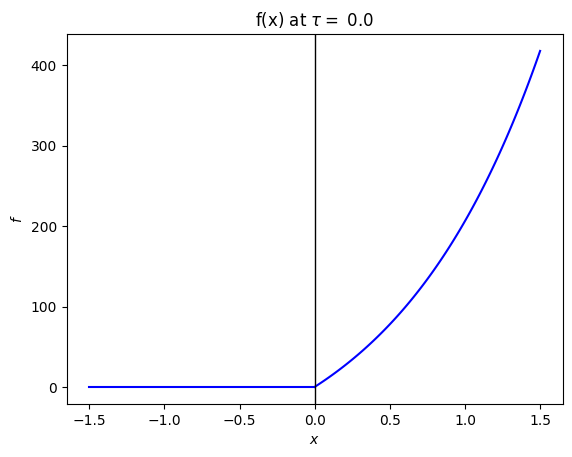

In [12]:
plot_frame(0)

## Transform PDE Problem to 2-chebyshev cell coordinates

$$ \partial_\tau f = \frac{1}{2} \sigma^2 (\frac{2}{w})^2 \partial^2_{xnum} f +(r - q - \frac{1}{2}\sigma^2) \frac{2}{w}\partial_{xnum} f - rf$$

$$ f(\tau, xnumleft =+1)  - f(\tau, xnumright = -1)  = 0$$

$$ \frac{2}{w}\partial_{xnumleft} f(\tau, xnumleft =+1) - \frac{2}{w}\partial_{xnumright} f(\tau, xnumright =-1) = 0$$

$$ f(\tau, xnumleft=-1) = 0$$

$$ f(\tau, xnumright = 1) - K(e^we^{-q \tau} - e^{-r \tau}) = 0 $$

## Method of Lines Solution with DIRK

In [13]:
a11 = 4.772644573858262e-01
c1 = a11

a21 = -1.970525884150017e-01
a22 = 4.763634284595835e-01
c2 = a21 + a22

a31 = -3.476744303729656e-02
a32 = 6.330518073354831e-01
a33 = 1.936343100750279e-01
c3 = a31 + a32 + a33

a41 = 9.677976685787021e-02
a42 = -1.935335264665350e-01
a43 = -2.076229458004729e-04
a44 = 1.595722048494314e-01
c4 = a41 + a42 + a43 + a44

a51 = 1.625272318198749e-01
a52 = -2.496725135473825e-01
a53 = -4.590799720417948e-02
a54 = 3.657947640085904e-01
a55 = 2.557528383076989e-01
c5 = a51 + a52 + a53 + a54 + a55

a61 = -7.076031971712624e-03
a62 = 8.462998548602952e-01
a63 = 3.440200169250181e-01
a64 = -7.209260545488652e-02
a65 = -2.154923319808753e-01
a66 = 1.043410976221611e-01
c6 = a61 + a62 + a63 + a64 + a65 + a66


a71 = 1.768579351797444e-03
a72 = 7.799600131275149e-02
a73 = 3.033332775645574e-01
a74 = 2.131608067328356e-01
a75 = 3.517693203190381e-01
a76 = -3.815458943865381e-01
a77 = 4.335179091055582e-01
c7 = a71 + a72 + a73 + a74 + a75 + a76 + a77

a81 = 0.000000000000000e+00
a82 = 2.273235341055902e-01
a83 = 3.084158379801177e-01
a84 = 1.572634195730069e-01
a85 = 2.435511371522748e-01
a86 = -1.209536267328315e-01
a87 = -8.026784733998993e-02
a88 =  2.646675452618318e-01
c8 = a81 + a82 + a83 + a84 + a85 + a86 + a87 + a88

b1 = a81
b2 = a82
b3 = a83
b4 = a84
b5 = a85
b6 = a86
b7 = a87
b8 = a88

In [14]:
def calc_T_matrix(dim, xcol):
    T = np.zeros(dim)
    for i in range(0,dim):
        T[i] = chebyshevs[i](xcol)
    return T

#Gauss-Lobatto Nodes
xcol = np.cos(np.pi*np.linspace(1, n-2, int(n-3/1 + 1))/(n-1))

#collocation matrices
Tcol = np.zeros((len(xcol),n))
for i in range(0, len(xcol)):
    Tcol[i,:] = calc_T_matrix(n, xcol[i])
    
Tdiffcol = np.matmul(Tcol, diff)
Tdiff2col = np.matmul(np.matmul(Tcol, diff), diff)


In [15]:
def calc_K(c, tau_inp, dtau_inp, K1, K2, K3, K4, K5, K6, K7, key):

    dtau = dtau_inp

    if key == 1:
        tau = tau_inp + dtau*c1
    elif key == 2:
        tau = tau_inp + dtau*c2
    elif key == 3:
        tau = tau_inp + dtau*c3
    elif key == 4:
        tau = tau_inp + dtau*c4
    elif key == 5:
        tau = tau_inp + dtau*c5
    elif key == 6:
        tau = tau_inp + dtau*c6
    elif key == 7:
        tau = tau_inp + dtau*c7
    elif key == 8:
        tau = tau_inp + dtau*c8
    

    L = np.zeros((2*n, 2*n))
    R = np.zeros((2*n, 2*n))
    J = np.zeros((2*n))
        
    #prepare the matrices
    
###################################################################################################
  
    #left outermost

    L[0:len(xcol),0:n] = Tcol 
    sigma_lv_vals = sigma_lv( K*np.exp(xnum_to_xleft(xcol)), T - tau)
    R[0:len(xcol),0:n] = (1/2)*(2/w)**2*(sigma_lv_vals**2.*Tdiff2col.T).T + (2/w)*((r - q - (1/2)*sigma_lv_vals**2.)*Tdiffcol.T).T + (-r)*Tcol
    
    row_count = len(xcol)    
    
#####################################################################################################################################
    
   
    #right outermost cell
    
    L[row_count:row_count + len(xcol),n:] = Tcol 
    sigma_lv_vals = sigma_lv( K*np.exp(xnum_to_xright(xcol)), T - tau)
    R[row_count:row_count + len(xcol),n:] = (1/2)*(2/w)**2*(sigma_lv_vals**2.*Tdiff2col.T).T + (2/w)*((r - q - (1/2)*sigma_lv_vals**2.)*Tdiffcol.T).T + (-r)*Tcol
    
    row_count = row_count + len(xcol)
    
#############################################################################################################################################
    
    #boundary conditions

    #left cell
    R[row_count, 0:n] = calc_T_matrix(n, -1.)

    row_count = row_count + 1

    #right cell
    R[row_count, n:] = calc_T_matrix(n, +1.) 
    J[row_count] =  K*(np.exp(w - q*tau) - np.exp(-r*tau))

    row_count = row_count + 1
    
    
####################################################################################################################################################
    

    #interface conditions
    TL = calc_T_matrix(n, +1.0)
    TR = calc_T_matrix(n, -1.0)
    TLdiff = np.matmul(TL, diff) 
    TRdiff = np.matmul(TR, diff) 

    #continuity
    
    R[row_count, 0:n] = -1*TL
    R[row_count, n:] = 1*TR
        
    row_count = row_count + 1
    
   
    #differentiability

    R[row_count, 0:n] = -(2/w)*TLdiff 
    R[row_count, n: ] = +(2/w)*TRdiff
    
    row_count = row_count + 1
    
    if key == 1:
        Lbar = L - R*(dtau)*(a11)
        Rbar = np.matmul(R, c) - J
        K1 = np.linalg.solve(Lbar,Rbar)
        return K1
    elif key == 2:
        Lbar = L - R*(dtau)*(a22)
        Rbar = np.matmul(R, c + dtau*K1*a21) - J
        K2 = np.linalg.solve(Lbar,Rbar)
        return K2
    elif key == 3:
        Lbar = L - R*(dtau)*(a33)
        Rbar = np.matmul(R, c + dtau*K1*a31 + dtau*K2*a32) - J
        K3 = np.linalg.solve(Lbar,Rbar)
        return K3
    elif key == 4:
        Lbar = L - R*(dtau)*(a44)
        Rbar = np.matmul(R, c + dtau*K1*a41 + dtau*K2*a42 + dtau*K3*a43) - J
        K4 = np.linalg.solve(Lbar,Rbar)
        return K4
    elif key == 5:
        Lbar = L - R*(dtau)*(a55)
        Rbar = np.matmul(R, c + dtau*K1*a51 + dtau*K2*a52 + dtau*K3*a53 + dtau*K4*a54) - J
        K5 = np.linalg.solve(Lbar,Rbar)
        return K5
    elif key == 6:
        Lbar = L - R*(dtau)*(a66)
        Rbar = np.matmul(R, c + dtau*K1*a61 + dtau*K2*a62 + dtau*K3*a63 + dtau*K4*a64 + dtau*K5*a65) - J
        K6 = np.linalg.solve(Lbar,Rbar)
        return K6
    elif key == 7:
        Lbar = L - R*(dtau)*(a77)
        Rbar = np.matmul(R, c + dtau*K1*a71 + dtau*K2*a72 + dtau*K3*a73 + dtau*K4*a74 + dtau*K5*a75 + dtau*K6*a76) - J
        K7 = np.linalg.solve(Lbar,Rbar)
        return K7
    elif key == 8:
        Lbar = L - R*(dtau)*(a88)
        Rbar = np.matmul(R, c + dtau*K1*a81 + dtau*K2*a82 + dtau*K3*a83 + dtau*K4*a84 + dtau*K5*a85 + dtau*K6*a86 + dtau*K7*a87) - J
        K8 = np.linalg.solve(Lbar,Rbar)
        return K8
    

In [16]:
#Calculate Data for all Times

for i in range(0, len(tau)-1):
    K1 = calc_K(c[i,:],tau[i], dtau[i], None, None, None, None, None, None, None, 1)
    K2 = calc_K(c[i,:],tau[i], dtau[i], K1, None, None, None, None, None, None, 2)
    K3 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, None, None, None, None, None, 3)
    K4 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, None, None, None, None, 4)
    K5 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, K4 , None, None, None, 5)
    K6 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, K4 , K5, None, None, 6)
    K7 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, K4 , K5, K6, None, 7)
    K8 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, K4 , K5, K6, K7, 8)

    c[i+1,:] = c[i,:] + dtau[i]*(b1*K1 + b2*K2 +b3*K3 + b4*K4 + b5*K5 + b6*K6 + b7*K7 + b8*K8)
    
    if i%100==0:
        print(i)
        print('The time is: '+str(tau[i]))
        print('The average of the Chebychev coefficients is: '+str(np.mean(np.abs(c[i,:]))))

0
The time is: 0.0
The average of the Chebychev coefficients is: 4.1780268844056785
100
The time is: 0.1
The average of the Chebychev coefficients is: 4.215134301285856
200
The time is: 0.2
The average of the Chebychev coefficients is: 4.226958873851285
300
The time is: 0.3
The average of the Chebychev coefficients is: 4.235416744559957
400
The time is: 0.4
The average of the Chebychev coefficients is: 4.242409116248819
500
The time is: 0.5
The average of the Chebychev coefficients is: 4.2483725089782425
600
The time is: 0.6
The average of the Chebychev coefficients is: 4.253953702372776
700
The time is: 0.7000000000000001
The average of the Chebychev coefficients is: 4.25907651204259
800
The time is: 0.8
The average of the Chebychev coefficients is: 4.264025067778594
900
The time is: 0.9
The average of the Chebychev coefficients is: 4.269055684246057


## Analysis

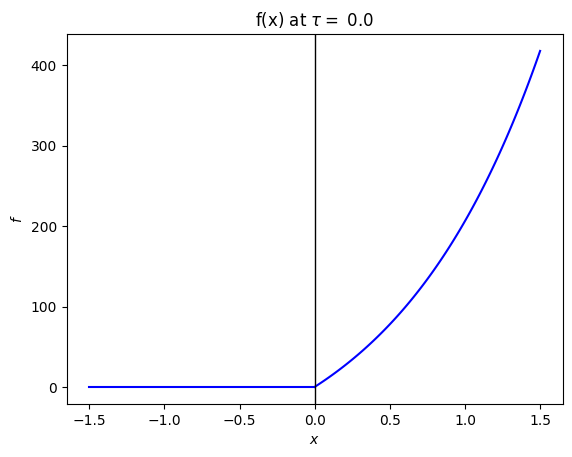

In [17]:
plot_frame(0)

In [18]:
def plot_coeff(tau_index):
    plt.plot(np.log10(np.abs(c[tau_index, 0:n])), c='red', label = 'left')
    plt.plot(np.log10(np.abs(c[tau_index, n:])), c='blue', label = 'right')
    plt.xlabel(r'$k$')
    plt.ylabel(r'$log_{10}|c_k|$')
    plt.legend()
    plt.show()

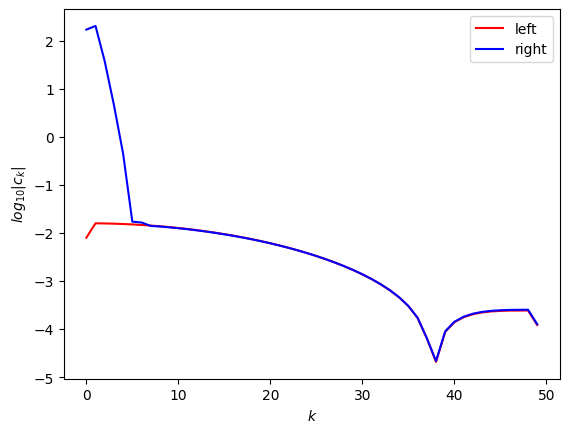

In [19]:
plot_coeff(1)

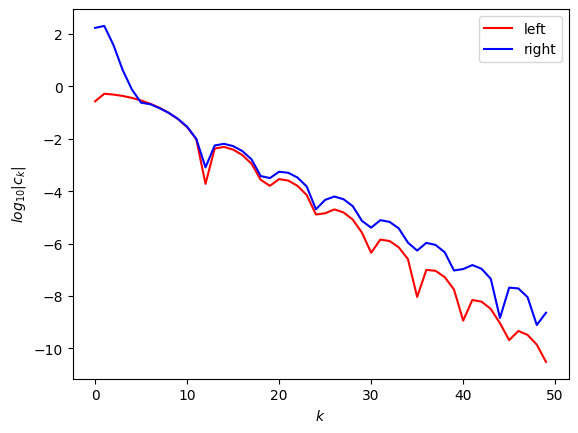

In [20]:
plot_coeff(100)

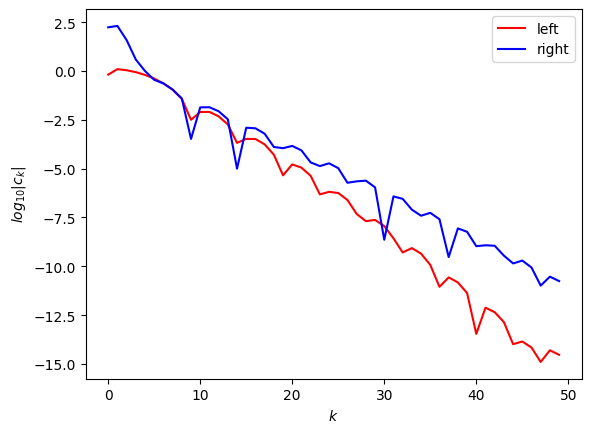

In [21]:
plot_coeff(300)

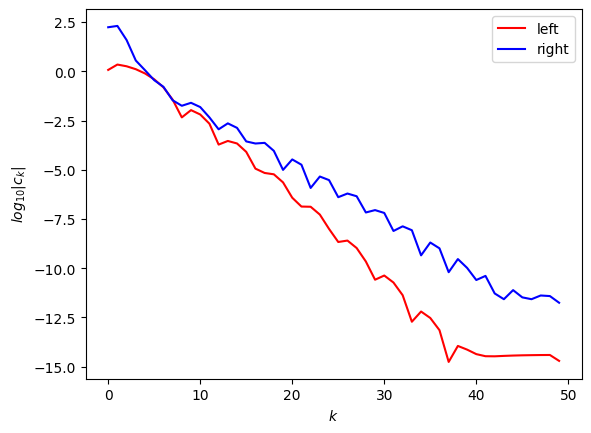

In [22]:
plot_coeff(600)

Fall of coefficients progressively gets better, as the solution becomes less and less kinky

In [23]:
def xleft_to_xnum(xleft):
    return (2/w)*xleft + 1.

def xright_to_xnum(xright):
    return (2/w)*xright - 1.

### Value to Compare with the backward solver. This is for any generic $\sigma$

$$ B(S = S_0, \tau = T)_K = F(K, T)_{S_0}$$

In [24]:
#when S0=100, x= ln(100/K) = ln(100/120) = ln(5/6)
# choose tau = T = 1,  index = -1

print(calc_u(c[-1,0:n], xleft_to_xnum(np.log(5/6))))

3.0475120569681478


## Movie

In [25]:
def plot_frame_movie(index, ax):

    #left part
  
    ax.plot(K*np.exp(xnum_to_xleft(xplot)), calc_u(c[index,0:n], xplot), c='blue')
       
    #right part
   
    ax.plot(K*np.exp(xnum_to_xright(xplot)), calc_u(c[index,n:], xplot), c='blue')
    

    
    ax.axvline(x=100, c='red', linestyle='dashed')
    ax.axvline(x=120, c='green', linestyle='dashed')
    ax.annotate(r'$\text{Strike}(K)=120$' ,(150,300), c='green', fontsize=15)
   
    ax.axhline(y=calc_u(c[index,0:n], xleft_to_xnum(np.log(5/6))), c='red', linestyle='dashed')
    ax.annotate(f'C(S=100,t= {T-tau[index]:.2f}) = {calc_u(c[index,0:n], xleft_to_xnum(np.log(5/6))):.2f}', (200, 20), c='red', fontsize=15)

    ax.set_xlabel(r'$\text{Stock Price}(S)$', fontsize=20)
    ax.set_ylabel(r'$\text{Call Price}(C)$', fontsize=20)
    ax.set_title('Black Scholes PDE', fontsize=20)
    ax.grid()

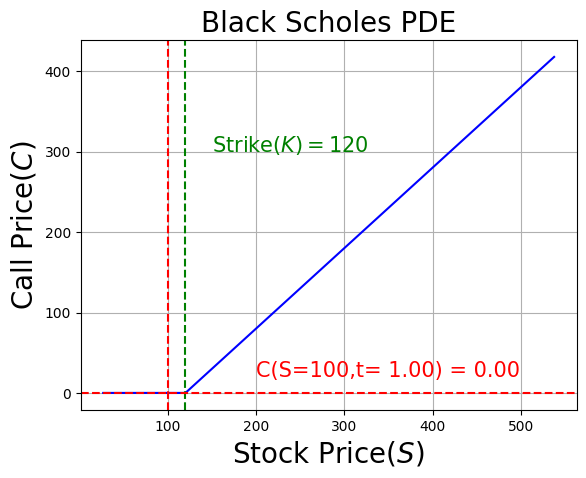

In [26]:
fig, ax = plt.subplots()
plot_frame_movie(1,ax)
plt.show()

In [27]:
from matplotlib.animation import PillowWriter

In [ ]:
metadata = dict(title='Movie', artist ='ayush_roy')
writer = PillowWriter(fps=10, metadata = metadata)

In [ ]:
fig, ax = plt.subplots()

with writer.saving(fig, 'blackscholes_pde.gif',100):
    for i in range(0, len(tau)):
        if i%4 == 0:
            plot_frame_movie(i, ax)
            writer.grab_frame()
            ax.clear()
        if i == len(tau)-1:
            for j in range(0,30):
                plot_frame_movie(i, ax)
                writer.grab_frame()
                ax.clear()

### Heatmap of errors with fixed N and timestep for $\sigma = \sigma_0$

In [28]:

def euro_call(S, K, tau, r, q, sig):

    d1 = (np.log(S/K) + (r-q+0.5*sig**2)*tau)/(sig*np.sqrt(tau))
    d2 = d1 - sig*np.sqrt(tau)
    return S*np.exp(-q*tau)*scipy.stats.norm.cdf(d1) - K*np.exp(-r*tau)*scipy.stats.norm.cdf(d2)

In [29]:
# heatmap of errors

#pass in solution array

def call_heatmap(c):

    numerical_solution = np.zeros((len(tau), 2*len(xplot)))
    analytical_solution = np.zeros((len(tau), 2*len(xplot)))

    for i in range(0, len(tau)):
        numerical_solution[i,:len(xplot)] = calc_u(c[i,0:n], xplot)
        analytical_solution[i,:len(xplot)] = euro_call(K*np.exp(xnum_to_xleft(xplot)), K, tau[i], r, q, sigma_lv(K*np.exp(xnum_to_xleft(xplot)), T - tau[i]))
        
        numerical_solution[i,len(xplot):] = calc_u(c[i,n:], xplot)
        analytical_solution[i,len(xplot):] = euro_call(K*np.exp(xnum_to_xright(xplot)), K, tau[i], r, q, sigma_lv(K*np.exp(xnum_to_xright(xplot)), T - tau[i]))
        
    errors = np.abs(numerical_solution - analytical_solution)

    return numerical_solution, analytical_solution, errors

In [30]:
num_call, ana_call, errors_call = call_heatmap(c)

C:\Users\Ayush Roy\AppData\Local\Temp\ipykernel_28364\818691313.py:3: RuntimeWarning: divide by zero encountered in divide
  d1 = (np.log(S/K) + (r-q+0.5*sig**2)*tau)/(sig*np.sqrt(tau))
C:\Users\Ayush Roy\AppData\Local\Temp\ipykernel_28364\818691313.py:3: RuntimeWarning: invalid value encountered in divide
  d1 = (np.log(S/K) + (r-q+0.5*sig**2)*tau)/(sig*np.sqrt(tau))


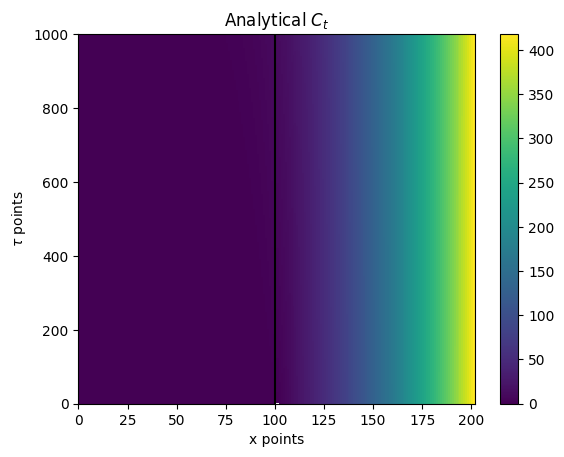

In [31]:
plt.pcolormesh(ana_call)
plt.title('Analytical '+r'$C_t$')
plt.xlabel('x points')
plt.ylabel(r'$\tau$'+' points')
plt.axvline(x=100, c='black')
plt.colorbar()

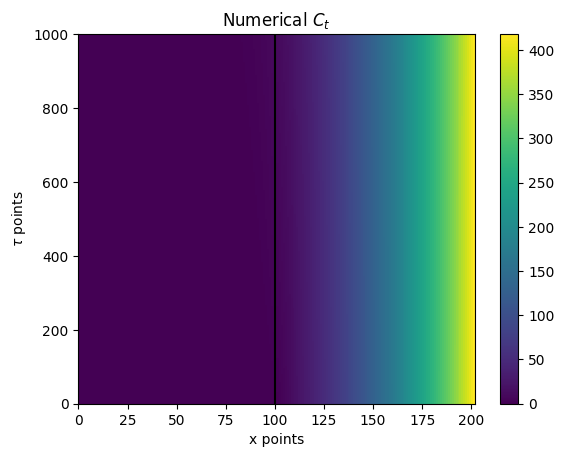

In [32]:
plt.pcolormesh(num_call)
plt.title('Numerical '+r'$C_t$')
plt.xlabel('x points')
plt.ylabel(r'$\tau$'+' points')
plt.axvline(x=100, c='black')
plt.colorbar()

C:\Users\Ayush Roy\AppData\Local\Temp\ipykernel_28364\958254640.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(np.log10(errors_call))


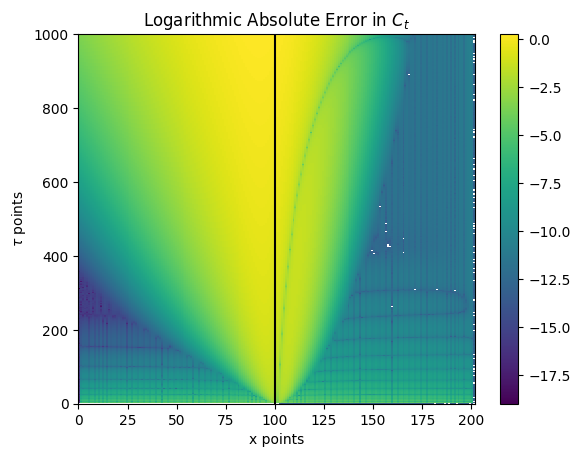

In [33]:
plt.pcolormesh(np.log10(errors_call))
plt.title('Logarithmic Absolute Error in '+r'$C_t$')
plt.xlabel('x points')
plt.ylabel(r'$\tau$'+' points')
plt.axvline(x=100, c='black')
plt.colorbar()